In [2]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import os

train_path = "../input/competitions/playground-series-s6e9/train.csv"
test_path = "../input/competitions/playground-series-s6e9/test.csv"

train_df = pd.read_csv(train_path, index_col="id")
test_df = pd.read_csv(test_path, index_col="id")
sample_submission_path = (
    "../input/competitions/playground-series-s6e9/sample_submission.csv"
)

In [3]:
print(f"train shape: {train_df.shape}")
print(f"test shape: {test_df.shape}")

print()
print("General info:")
train_df.info()
print()
print("Num of distinct values per column")
print(train_df.nunique())
print()
print("Num of missing values per column")
print(train_df.isna().sum())
print()
print("Detailed descrption of numeric cols")
train_df.describe()

train shape: (668665, 14)
test shape: (286571, 13)

General info:
<class 'pandas.core.frame.DataFrame'>
Index: 668665 entries, 0 to 668664
Data columns (total 14 columns):
 #   Column                       Non-Null Count   Dtype  
---  ------                       --------------   -----  
 0   Age                          668665 non-null  int64  
 1   Annual_Income_USD            668665 non-null  float64
 2   Daily_Commute_km             668665 non-null  float64
 3   Number_of_Cars_Owned         668665 non-null  int64  
 4   Charging_Stations_Near_Home  668665 non-null  int64  
 5   Charging_Stations_Near_Work  668665 non-null  int64  
 6   Environmental_Concern_Level  668665 non-null  float64
 7   Gender                       668665 non-null  object 
 8   City_Type                    668665 non-null  object 
 9   Current_Car_Type             668665 non-null  object 
 10  Home_Charging_Possible       668665 non-null  object 
 11  Subsidy_Available            668665 non-null  object 
 1

,Age,Annual_Income_USD,Daily_Commute_km,Number_of_Cars_Owned,Charging_Stations_Near_Home,Charging_Stations_Near_Work,Environmental_Concern_Level
count,668665.000000,668665.000000,668665.000000,668665.000000,668665.000000,668665.000000,668665.000000
mean,47.039171,84769.266989,32.158298,1.712626,4.960408,7.176314,2.935477
std,12.875448,28648.029042,18.730474,0.729275,3.926843,5.186627,1.429119
min,25.000000,30000.000000,5.000000,1.000000,0.000000,0.000000,1.000000
25%,36.000000,67376.000000,17.200000,1.000000,2.000000,3.000000,2.000000
50%,47.000000,84880.000000,33.600000,2.000000,4.000000,6.000000,3.000000
75%,58.000000,102753.000000,47.400000,2.000000,7.000000,10.000000,4.000000
max,69.000000,188549.000000,98.700000,4.000000,14.000000,19.000000,5.000000


In [4]:
train_df.head()

,Age,Annual_Income_USD,Daily_Commute_km,Number_of_Cars_Owned,Charging_Stations_Near_Home,Charging_Stations_Near_Work,Environmental_Concern_Level,Gender,City_Type,Current_Car_Type,Home_Charging_Possible,Subsidy_Available,Range_Anxiety_Level,Will_Buy_EV
id,,,,,,,,,,,,,,
0,66,92887.0,23.4,2,3,7,1.0,Male,Suburban,Sedan,Yes,No,Low,No
1,38,30000.0,5.0,1,2,2,4.0,Male,Rural,SUV,Yes,No,Low,No
2,26,94389.0,36.8,1,8,15,5.0,Female,Urban,Sedan,No,Yes,Low,Yes
3,66,73580.0,23.7,2,6,9,3.0,Male,Suburban,Hatchback,Yes,No,Low,No
4,54,57898.0,50.8,1,2,3,3.0,Male,Suburban,Hatchback,Yes,No,Low,No


In [6]:
numeric_features = train_features.select_dtypes(
    include="number"
).columns

numeric_comparison = pd.DataFrame({
    "train_mean": train_features[numeric_features].mean(),
    "test_mean": test_df[numeric_features].mean(),
    "train_median": train_features[numeric_features].median(),
    "test_median": test_df[numeric_features].median(),
    "train_std": train_features[numeric_features].std(),
    "test_std": test_df[numeric_features].std()
})

numeric_comparison

,train_mean,test_mean,train_median,test_median,train_std,test_std
Age,47.039171,47.070824,47.0,47.0,12.875448,12.864850
Annual_Income_USD,84769.266989,84799.508432,84880.0,84926.0,28648.029042,28626.851098
Daily_Commute_km,32.158298,32.159305,33.6,33.6,18.730474,18.724436
Number_of_Cars_Owned,1.712626,1.716095,2.0,2.0,0.729275,0.731088
Charging_Stations_Near_Home,4.960408,4.950693,4.0,4.0,3.926843,3.928626
Charging_Stations_Near_Work,7.176314,7.155626,6.0,6.0,5.186627,5.186880
Environmental_Concern_Level,2.935477,2.934554,3.0,3.0,1.429119,1.427541


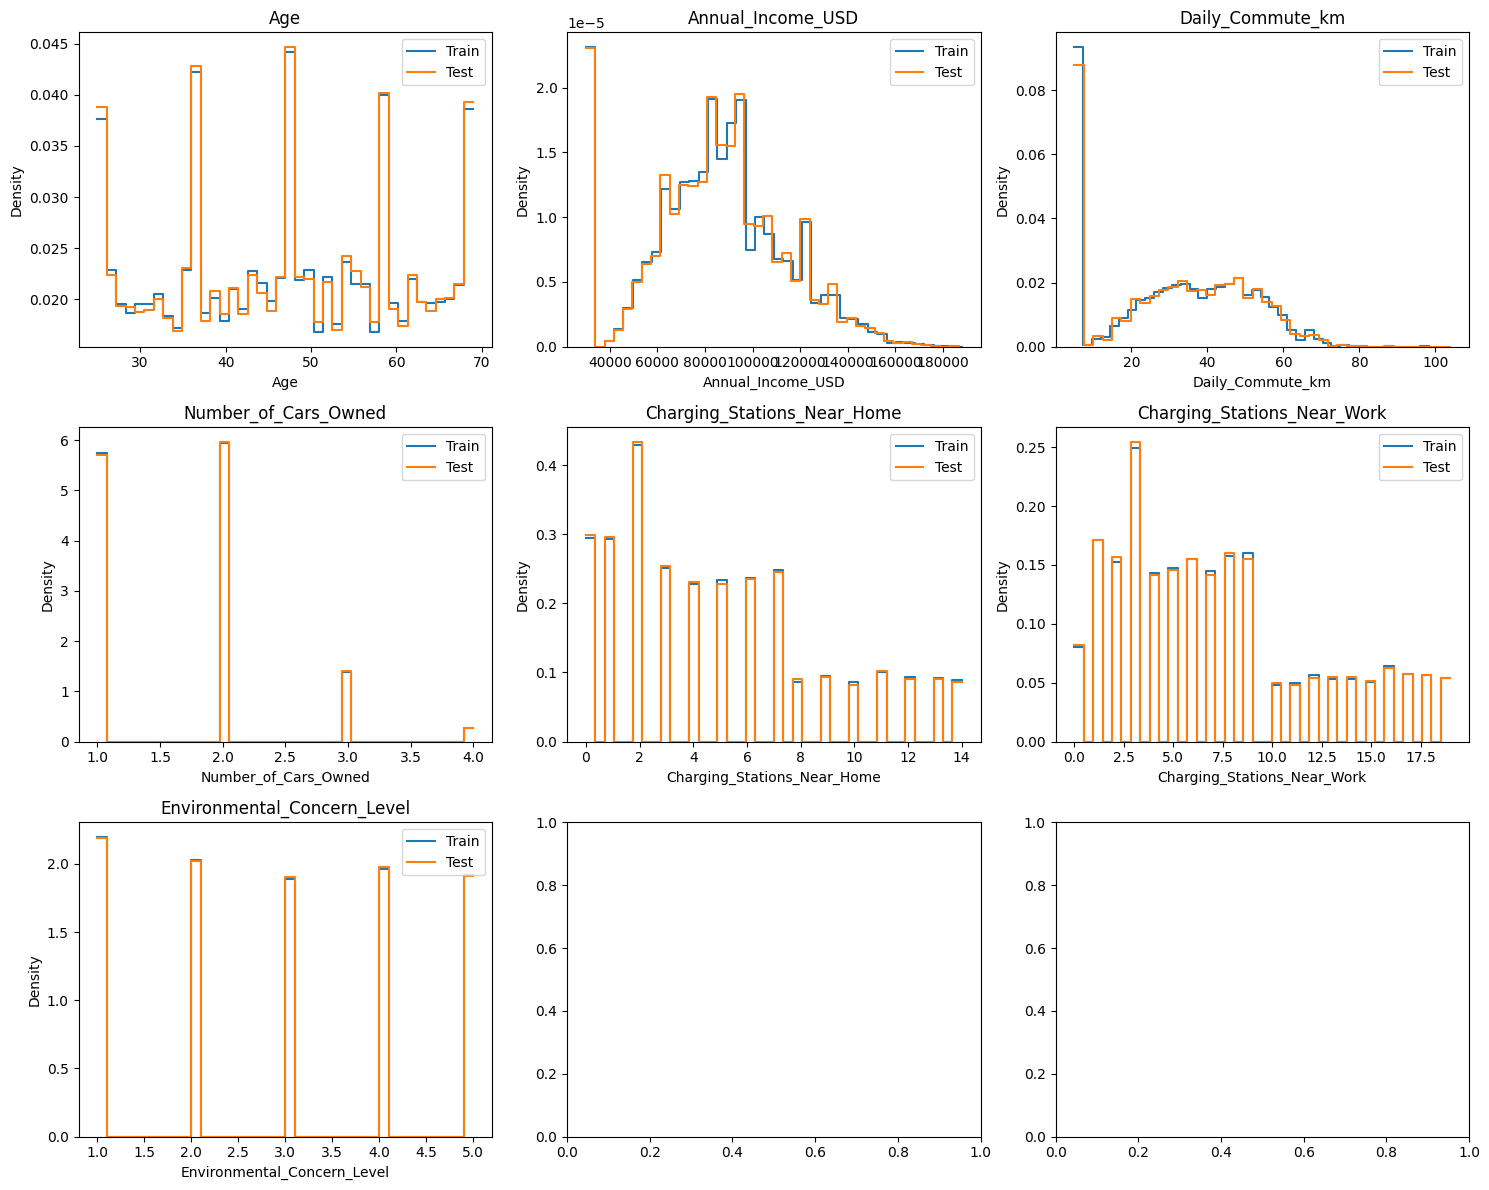

In [7]:
train_sample = train_features.sample(
    100_000,
    random_state=42
)

test_sample = test_df.sample(
    100_000,
    random_state=42
)

fig, axes = plt.subplots(3, 3, figsize=(15, 12))

for col, ax in zip(numeric_features, axes.flat):
    sns.histplot(
        train_sample[col],
        bins=40,
        stat="density",
        element="step",
        fill=False,
        label="Train",
        ax=ax
    )

    sns.histplot(
        test_sample[col],
        bins=40,
        stat="density",
        element="step",
        fill=False,
        label="Test",
        ax=ax
    )

    ax.set_title(col)
    ax.legend()

plt.tight_layout()
plt.show()

Baseline catboost model

In [8]:
from catboost import CatBoostClassifier
from sklearn.model_selection import train_test_split
from sklearn.metrics import roc_auc_score

TARGET = "Will_Buy_EV"
SEED = 42

X = train_df.drop(columns=TARGET)
y = train_df[TARGET].map({"No": 0, "Yes": 1})
X_test = test_df.loc[:, X.columns]

cat_features = X.select_dtypes(include=["object", "string"]).columns.tolist()

X_fit, X_valid, y_fit, y_valid = train_test_split(
    X,
    y,
    test_size=0.20,
    stratify=y,
    random_state=SEED,
)

print(f"Training rows: {len(X_fit):,}")
print(f"Validation rows: {len(X_valid):,}")
print(f"Buyer proportion: {y.mean():.2%}")

Training rows: 534,932
Validation rows: 133,733
Buyer proportion: 17.46%


In [9]:
params = dict(
    loss_function="Logloss",
    eval_metric="AUC",
    depth=6,
    learning_rate=0.08,
    random_seed=SEED,
    task_type="CPU",
    thread_count=4,
    counter_calc_method="SkipTest",
    allow_writing_files=False,
)

model = CatBoostClassifier(**params, iterations=1600)

model.fit(
    X_fit,
    y_fit,
    cat_features=cat_features,
    eval_set=(X_valid, y_valid),
    early_stopping_rounds=120,
    use_best_model=True,
    verbose=100,
)

valid_pred = model.predict_proba(X_valid)[:, 1]
valid_auc = roc_auc_score(y_valid, valid_pred)
best_iterations = model.tree_count_

print(f"\nHoldout ROC-AUC: {valid_auc:.6f}")
print(f"Selected trees: {best_iterations}")

# Save predictions for comparisons with future experiments.
pd.DataFrame({
    "id": X_valid.index,
    "target": y_valid.to_numpy(),
    "prediction": valid_pred,
}).to_csv("/kaggle/working/holdout_predictions.csv", index=False)

0:	test: 0.9289273	best: 0.9289273 (0)	total: 334ms	remaining: 8m 54s
100:	test: 0.9400379	best: 0.9400379 (100)	total: 23.3s	remaining: 5m 45s
200:	test: 0.9406784	best: 0.9406784 (200)	total: 45.8s	remaining: 5m 19s
300:	test: 0.9411107	best: 0.9411107 (300)	total: 1m 9s	remaining: 5m
400:	test: 0.9413346	best: 0.9413346 (400)	total: 1m 33s	remaining: 4m 39s
500:	test: 0.9414302	best: 0.9414309 (497)	total: 1m 57s	remaining: 4m 17s
600:	test: 0.9414788	best: 0.9414788 (600)	total: 2m 20s	remaining: 3m 54s
700:	test: 0.9415130	best: 0.9415132 (699)	total: 2m 44s	remaining: 3m 31s
800:	test: 0.9415318	best: 0.9415322 (795)	total: 3m 8s	remaining: 3m 7s
900:	test: 0.9415497	best: 0.9415521 (887)	total: 3m 31s	remaining: 2m 44s
1000:	test: 0.9415580	best: 0.9415595 (957)	total: 3m 55s	remaining: 2m 20s
Stopped by overfitting detector  (120 iterations wait)

bestTest = 0.9415595485
bestIteration = 957

Shrink model to first 958 iterations.

Holdout ROC-AUC: 0.941560
Selected trees: 958


In [10]:
final_model = CatBoostClassifier(
    **params,
    iterations=best_iterations,
)

final_model.fit(
    X,
    y,
    cat_features=cat_features,
    verbose=100,
)

test_pred = final_model.predict_proba(X_test)[:, 1]

submission = pd.read_csv(sample_submission_path, index_col="id")
assert submission.columns.tolist() == [TARGET]
assert submission.index.equals(X_test.index)
assert submission.index.is_unique
assert np.isfinite(test_pred).all()
assert ((test_pred >= 0) & (test_pred <= 1)).all()

submission[TARGET] = test_pred
submission.to_csv("/kaggle/working/submission.csv", index_label="id")

print("Saved submission.csv:", submission.shape)
display(submission.head())

0:	total: 303ms	remaining: 4m 50s
100:	total: 26.1s	remaining: 3m 41s
200:	total: 51.7s	remaining: 3m 14s
300:	total: 1m 18s	remaining: 2m 50s
400:	total: 1m 44s	remaining: 2m 24s
500:	total: 2m 10s	remaining: 1m 59s
600:	total: 2m 37s	remaining: 1m 33s
700:	total: 3m 3s	remaining: 1m 7s
800:	total: 3m 30s	remaining: 41.2s
900:	total: 3m 56s	remaining: 15s
957:	total: 4m 12s	remaining: 0us
Saved submission.csv: (286571, 1)


,Will_Buy_EV
id,
668665,0.010562
668666,0.021252
668667,0.004296
668668,0.002308
668669,0.024525
